In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# import local toolkit (try normal import first, fall back to loading from file)
try:
	import inequality_analyzers as inqA
except Exception:
	import importlib.util
	toolkit_path = repo_root / 'Code' / 'tools' / 'inequality_analyzers.py'
	if toolkit_path.exists():
		spec = importlib.util.spec_from_file_location("inequality_analyzers", str(toolkit_path))
		stk = importlib.util.module_from_spec(spec)
		spec.loader.exec_module(stk)
	else:
		raise

In [2]:
# Load the data file with deflated income_hh
data_file = data_root / 'CBOS_data_final_deflated_income.csv'
df = pd.read_csv(data_file)

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_600/673112059.py:3: DtypeWarning: Columns (14,15,20,21,22,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file)


In [3]:
df

,org_id,survey file,survey year,survey month,age,year_born,sex,sex_L,city_size,city_size_L,...,income_p_OLD_T,income_p_NEW_T,income_p_T,income_p_OLD_T_L,income_p_NEW_T_L,income_p_T_L,weight,survey_date,income_hh_ALL,income_hh_deflated
0,1.0,CBOS_1_01_1990.sav,1990,1,0,1957.0,2.0,Kobieta,9.0,Miasto powyżej 500 tys. mieszkańców,...,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,NaN,38.000000
1,2.0,CBOS_1_01_1990.sav,1990,1,0,1950.0,2.0,Kobieta,9.0,Miasto powyżej 500 tys. mieszkańców,...,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,NaN,40.000000
2,3.0,CBOS_1_01_1990.sav,1990,1,0,1932.0,2.0,Kobieta,9.0,Miasto powyżej 500 tys. mieszkańców,...,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,NaN,17.000000
3,4.0,CBOS_1_01_1990.sav,1990,1,0,1946.0,1.0,Mężczyzna,9.0,Miasto powyżej 500 tys. mieszkańców,...,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,NaN,37.500000
4,5.0,CBOS_1_01_1990.sav,1990,1,0,1939.0,1.0,Mężczyzna,9.0,Miasto powyżej 500 tys. mieszkańców,...,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,NaN,43.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358520,921.0,CBOS_331_12_2017.sav,2017,12,0,1957.0,1.0,Mężczyzna,1.0,wieś,...,0.0,0,0.0,NaN,NaN,NaN,0.611965,2017-12-01,NaN,NaN
358521,922.0,CBOS_331_12_2017.sav,2017,12,0,1981.0,1.0,Mężczyzna,1.0,wieś,...,0.0,0,0.0,NaN,NaN,NaN,1.127158,2017-12-01,NaN,61.934773
358522,923.0,CBOS_331_12_2017.sav,2017,12,0,1976.0,1.0,Mężczyzna,5.0,miasto od 100 000 do 499 999,...,0.0,0,0.0,NaN,NaN,NaN,1.716070,2017-12-01,NaN,37.160864
358523,924.0,CBOS_331_12_2017.sav,2017,12,0,1971.0,2.0,Kobieta,5.0,miasto od 100 000 do 499 999,...,0.0,0,0.0,NaN,NaN,NaN,1.572886,2017-12-01,NaN,61.934773


In [ ]:
IA = inqA.InequalityAnalyzer(df, income_col='income_hh_deflated', annual_frequency = True)

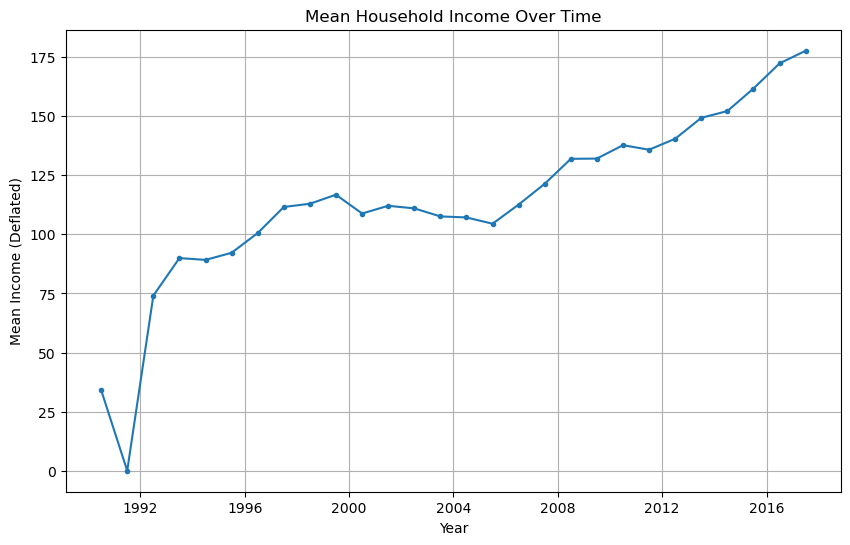

In [14]:
# Plot the time series of mean
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(IA.time_series['weighted_mean_total'], marker='.')
plt.title('Mean Household Income Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Income (Deflated)')
plt.grid()
plt.show()

In [5]:
# Missing values or equal to 0.0 of old location per year and month
missing_locations = df[df['location_old'].isna() | (df['location_old'] == 0.0)].groupby(['survey year', 'survey month']).size().reset_index(name='missing_count')
missing_locations

# Old voivodeships are not supported beginning from 03/2000.

,survey year,survey month,missing_count
0,1990,1,68
1,1990,3,1
2,1990,6,1
3,1991,5,23
4,1991,7,23
...,...,...,...
215,2017,8,1009
216,2017,9,985
217,2017,10,948
218,2017,11,1016


In [6]:
# Now missing values or equal to 0.0 of new location per year and month
missing_locations_new = df[df['location_new'].isna() | (df['location_new'] == 0.0)].groupby(['survey year', 'survey month']).size().reset_index(name='missing_count')
missing_locations_new

# New voivodeships are supported beginning from 01/1999.

,survey year,survey month,missing_count
0,1990,1,1486
1,1990,2,1498
2,1990,3,1502
3,1990,4,1387
4,1990,5,1474
...,...,...,...
96,1998,8,1085
97,1998,9,1126
98,1998,10,1094
99,1998,11,1114


In [7]:
# Consider time from the beginning of 1990 till 03/2000.
df_old = df[(df['survey year'] < 2000) | ((df['survey year'] == 2000) & (df['survey month'] <= 3))]

In [8]:
for year in set(df_old['survey year']):
    df_temp = df_old[df_old['survey year'] == year]
    # Sort by income_hh_deflated
    df_temp = df_temp.sort_values(by='income_hh_deflated').reset_index(drop=True)
    # Group by old location and display number of observations and mean income_hh
    summary = df_temp.groupby('location_old_L').agg(
        n_obs = ('income_hh_deflated', 'size'),
        mean_income_hh = ('income_hh_deflated', 'mean'),
        mean_top1_income_hh = ('income_hh_deflated', lambda x: np.mean(x.nlargest(int(0.01 * len(x))) ) ),
        mean_top10_income_hh = ('income_hh_deflated', lambda x: np.mean(x.nlargest(int(0.1 * len(x))) ) ),
        mean_middle40_income_hh = ('income_hh_deflated', lambda x: np.mean(x.iloc[int(0.1 * len(x)):int(0.5 * len(x))] ) ),
        mean_bottom50_income_hh = ('income_hh_deflated', lambda x: np.mean(x.nsmallest(int(0.5 * len(x))) ) )
    ).reset_index()
    print(f"Year: {year} with {len(summary)} regions")
    display(summary.sort_values(by='location_old_L'))

Year: 1990 with 49 regions


,location_old_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,Bialsko-Podlaskie,483,18.752348,97.218484,47.735197,12.034846,9.637864
1,Białostockie,731,18.583327,119.860806,50.758828,11.204683,8.963746
2,Bielskie,616,19.743934,245.500000,67.563030,8.071553,6.472966
3,Bydgoskie,561,14.468810,117.853588,48.288124,2.967283,2.373826
4,Chełmskie,112,11.171132,86.591988,45.005797,0.432253,0.347346
5,Ciechanowskie,100,11.624661,68.873935,55.068058,0.000000,0.000000
6,Częstochowskie,300,11.536033,71.215855,38.808438,0.084049,0.067239
7,Elbląskie,139,9.804919,48.211755,35.832788,0.000000,0.000000
8,Gdańskie,569,12.600430,105.415459,48.159232,0.000000,0.000000
9,Gorzowskie,202,12.217435,143.547195,45.467885,0.000000,0.000000


Year: 1991 with 49 regions


,location_old_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,bialskopodlaskie,88,0.0,NaN,0.0,0.0,0.0
1,białostockie,258,0.0,0.0,0.0,0.0,0.0
2,bielskie,315,0.0,0.0,0.0,0.0,0.0
3,bydgoskie,403,0.0,0.0,0.0,0.0,0.0
4,chełmskie,99,0.0,NaN,0.0,0.0,0.0
5,ciechanowskie,135,0.0,0.0,0.0,0.0,0.0
6,częstochowskie,256,0.0,0.0,0.0,0.0,0.0
7,elbląskie,158,0.0,0.0,0.0,0.0,0.0
8,gdańskie,534,0.0,0.0,0.0,0.0,0.0
9,gorzowskie,154,0.0,0.0,0.0,0.0,0.0


Year: 1992 with 50 regions


...

,location_old_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,bialskopodlaskie,134,27.403407,73.762587,53.951140,20.708958,18.339813
1,białostockie,288,32.452730,150.651948,69.005739,23.873426,20.937847
2,bielskie,340,38.695060,278.424933,100.481299,26.376505,23.036442
3,bydgoskie,414,34.040416,195.418424,91.436336,21.930885,19.682681
4,chełmskie,110,31.625719,142.621177,78.109847,22.428743,19.611215
5,ciechanowskie,234,37.508570,472.532485,124.637683,21.781584,19.449450
6,częstochowskie,340,33.811401,158.229984,83.131823,23.588548,21.042321
7,elbląskie,126,30.632011,121.228001,72.140625,21.787269,19.090669
8,gdańskie,508,43.308247,217.389346,101.536721,29.938722,26.323043
9,gorzowskie,150,32.555513,142.623459,82.171448,20.097706,17.893130


Year: 1999 with 49 regions


,location_old_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,bialskopodlaskie,118,26.268541,67.448201,54.001130,20.692204,18.312038
1,białostockie,256,32.447910,160.685099,70.584343,25.901829,22.909106
2,bielskie,227,38.352595,413.156826,112.346866,24.485521,21.835690
3,bydgoskie,320,34.853043,169.040409,83.939694,23.675516,20.921017
4,chełmskie,49,33.886930,NaN,89.659101,20.126860,17.802410
5,ciechanowskie,212,33.294191,128.818616,75.953310,24.150796,21.544633
6,częstochowskie,188,31.460153,101.172301,62.876116,24.019855,21.418284
7,elbląskie,176,35.181476,201.140384,78.794860,25.855884,22.619238
8,gdańskie,454,44.261671,191.316272,105.270569,31.665579,28.032694
9,gorzowskie,153,32.585610,460.087171,94.141650,20.225062,17.679246


Year: 2000 with 49 regions


,location_old_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,bialskopodlaskie,10,43.997402,NaN,78.409887,43.727694,37.114904
1,białostockie,23,27.273604,NaN,51.840359,22.671777,20.810305
2,bielskie,34,35.781291,NaN,77.177917,26.981527,24.085133
3,bydgoskie,67,30.785528,NaN,68.319439,24.472105,22.201822
4,chełmskie,25,28.736854,NaN,62.168394,19.048085,17.434608
5,ciechanowskie,22,30.070023,NaN,51.526720,24.743435,22.230344
6,częstochowskie,52,29.882498,NaN,63.758662,23.327328,20.689976
7,elbląskie,47,27.761626,NaN,66.501532,16.074816,14.379860
8,gdańskie,72,39.129812,NaN,103.469523,25.277532,22.189465
9,gorzowskie,20,25.430313,NaN,33.570933,24.560634,22.022097


In [9]:
# Consider time from 01/1999 onward.
df_new = df[df['survey year'] > 1998]

In [10]:
for year in set(df_new['survey year']):
    df_temp = df_new[df_new['survey year'] == year]
    # Sort by income_hh_deflated
    df_temp = df_temp.sort_values(by='income_hh_deflated').reset_index(drop=True)
    # Group by new location and display number of observations and mean income_hh
    summary = df_temp.groupby('location_new_L').agg(
        n_obs = ('income_hh_deflated', 'size'),
        mean_income_hh = ('income_hh_deflated', 'mean'),
        mean_top1_income_hh = ('income_hh_deflated', lambda x: np.mean(x.nlargest(int(0.01 * len(x))) ) ),
        mean_top10_income_hh = ('income_hh_deflated', lambda x: np.mean(x.nlargest(int(0.1 * len(x))) ) ),
        mean_middle40_income_hh = ('income_hh_deflated', lambda x: np.mean(x.iloc[int(0.1 * len(x)):int(0.5 * len(x))] ) ),
        mean_bottom50_income_hh = ('income_hh_deflated', lambda x: np.mean(x.nsmallest(int(0.5 * len(x))) ) )
    ).reset_index()
    print(f"Year: {year} with {len(summary)} regions")
    display(summary.sort_values(by='location_new_L'))

Year: 1999 with 16 regions


,location_new_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,Dolnośląskie,1067,38.632512,179.872349,91.208943,27.639372,24.374264
1,Kujawsko-pomorskie,767,33.140442,177.808830,78.735494,22.841156,20.019051
2,Lubelskie,834,30.123981,129.446536,74.153003,20.366679,17.839223
3,Lubuskie,320,35.635168,238.718832,84.413873,25.262982,22.408986
4,Mazowieckie,1581,44.637796,348.481450,132.397083,27.674671,24.042703
5,Małopolskie,1033,35.456228,209.566055,87.091045,24.627624,21.553783
6,Opolskie,345,36.866329,203.865782,88.584386,25.361613,22.218403
7,Podkarpackie,671,32.319077,119.255230,71.727399,23.930959,20.961640
8,Podlaskie,397,29.798206,151.554674,65.281477,22.878728,19.768383
9,Pomorskie,720,40.185875,181.030131,100.946322,27.292749,24.016731


Year: 2000 with 16 regions


,location_new_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,Dolnośląskie,1117,35.077517,161.298387,81.145812,23.903628,21.031958
1,Kujawsko-pomorskie,734,31.875650,236.041773,81.062013,22.096408,19.308936
2,Lubelskie,769,32.326904,186.224402,81.714811,22.030742,19.270107
3,Lubuskie,338,34.339021,126.176427,70.899818,26.932953,23.761688
4,Mazowieckie,1588,42.823846,234.586291,111.164384,30.448891,26.278355
5,Małopolskie,865,32.659438,168.021295,76.809711,24.265797,21.160350
6,Opolskie,409,35.624997,249.215631,88.307176,24.585113,21.858735
7,Podkarpackie,628,29.111770,112.740193,65.401747,21.718540,18.930344
8,Podlaskie,438,29.808996,185.929586,72.458853,21.807564,19.112651
9,Pomorskie,728,39.578872,210.912040,93.125243,29.696286,25.845284


Year: 2001 with 16 regions


...

,location_new_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,Dolnośląskie,772,64.673130,292.452676,148.845601,49.410581,43.215910
1,Kujawsko-pomorskie,761,53.611988,172.291167,103.182270,62.774562,53.611988
2,Lubelskie,614,52.879756,260.710115,110.270853,52.003900,45.604964
3,Lubuskie,263,59.598404,316.412455,130.769725,47.826444,41.816841
4,Mazowieckie,1625,80.360144,395.963369,176.840116,96.652480,80.360144
5,Małopolskie,1005,62.882534,259.228263,125.858049,74.848055,62.882534
6,Opolskie,478,65.472943,307.100683,138.154898,58.358917,51.744246
7,Podkarpackie,806,52.549522,251.456685,120.478116,42.527940,37.052768
8,Podlaskie,364,58.425387,274.529954,125.373809,57.137562,49.263625
9,Pomorskie,735,70.290978,301.339373,143.743296,71.337039,61.758896


Year: 2016 with 16 regions


,location_new_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,Dolnośląskie,899,71.835536,265.662687,146.415193,62.195396,55.007911
1,Kujawsko-pomorskie,693,52.297043,141.308974,92.395275,61.323508,52.297043
2,Lubelskie,612,57.779555,340.483589,139.672020,46.710206,40.922744
3,Lubuskie,444,72.375104,308.055902,158.874608,62.724294,55.459680
4,Mazowieckie,1471,78.233601,396.254065,172.832044,92.670524,78.233601
5,Małopolskie,1137,65.872665,282.165279,124.890478,80.158587,65.872665
6,Opolskie,372,62.383204,212.144761,126.444221,55.253981,49.021812
7,Podkarpackie,725,59.725480,298.442786,135.966542,48.599442,43.070167
8,Podlaskie,441,61.071201,170.810892,118.489569,65.846030,57.239647
9,Pomorskie,827,81.315574,529.371102,199.544287,71.023779,61.465415


Year: 2017 with 22 regions


,location_new_L,n_obs,mean_income_hh,mean_top1_income_hh,mean_top10_income_hh,mean_middle40_income_hh,mean_bottom50_income_hh
0,Centralny,1725,72.123192,420.112114,164.043929,73.811811,63.795298
1,Dolnośląskie,155,73.052151,376.454379,164.931356,61.379942,54.958140
2,Kujawsko-pomorskie,109,57.133830,117.119140,93.355458,64.961147,57.133830
3,Lubelskie,115,54.661929,167.313058,96.695540,63.087802,54.661929
4,Lubuskie,85,61.228381,NaN,113.987249,60.675281,54.613950
5,Mazowieckie,226,67.423456,217.883429,132.944104,79.931641,67.423456
6,Małopolskie,158,61.604507,230.055454,108.448141,72.926928,61.604507
7,Opolskie,69,69.704792,NaN,145.297448,63.409595,57.399605
8,Podkarpackie,142,53.803168,167.814997,118.235059,46.142116,40.257348
9,Podlaskie,77,77.791322,NaN,201.772974,62.563007,55.767390
